In [6]:
import numpy as np
import pandas as pd

In [7]:
df = pd.read_csv("spam.csv", encoding='latin-1')

In [8]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3371,ham,And now electricity just went out fml.,NaN,NaN,NaN
1473,ham,"Will do, you gonna be at blake's all night? I ...",NaN,NaN,NaN
1999,ham,LMAO where's your fish memory when I need it?,NaN,NaN,NaN
96,ham,Watching telugu movie..wat abt u?,NaN,NaN,NaN
3158,ham,Are you up for the challenge? I know i am :),NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

In [10]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## 1. Data Cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [12]:
# DROP last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [13]:
df.sample(5)

,v1,v2
4743,ham,"\Thinking of u ;) x\"""""
4001,ham,Did you get any gift? This year i didnt get an...
884,ham,Yoyyooo u know how to change permissions for a...
2796,ham,If I get there before you after your ten billi...
2926,ham,Ok... U enjoy ur shows...


In [14]:
# renaming the columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.sample(5)

,target,text
1990,ham,HI DARLIN IVE JUST GOT BACK AND I HAD A REALLY...
3067,ham,Boy you best get yo ass out here quick
3657,ham,R u here yet? I'm wearing blue shirt n black p...
3423,spam,Am new 2 club & dont fink we met yet Will B gr...
1567,ham,"whatever, im pretty pissed off."


In [15]:
# DATA ENCODING
from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder() 

In [16]:
df['target'] = encoder.fit_transform(df['target'])

df.head()

In [17]:
# CHCEKING MISSING VALUES
df.isnull().sum()

target    0
text      0
dtype: int64

In [18]:
# check for duplicate values
df.duplicated().sum()

403

In [19]:
# remove duplicates
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

0

In [20]:
df.shape

(5169, 2)

## EDA

In [21]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
df['target'].value_counts() #to see ham spam ratio so here ham are more and spam are 653

target
0    4516
1     653
Name: count, dtype: int64

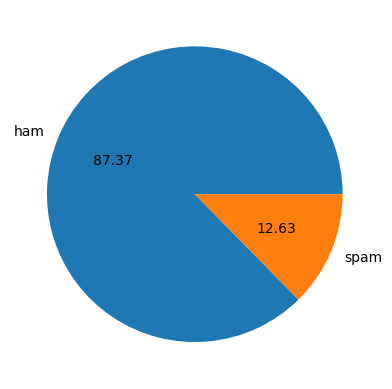

In [23]:
# to represent the ratio in diagram
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f') 
plt.show()


In [24]:
# IMBALANCED DATA

In [25]:
import nltk

In [26]:
!pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\AYUSHI
[nltk_data]     TYAGI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [36]:
df['num_characters'] = df['text'].apply(len)

In [37]:
df.head()

,target,text,num_words,num_sentences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111
1,0,Ok lar... Joking wif u oni...,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155
3,0,U dun say so early hor... U c already then say...,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61


In [38]:
# fetching no of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [39]:
df.head()

,target,text,num_words,num_sentences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111
1,0,Ok lar... Joking wif u oni...,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155
3,0,U dun say so early hor... U c already then say...,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61


In [40]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [41]:
df.head()

,target,text,num_words,num_sentences,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111
1,0,Ok lar... Joking wif u oni...,8,2,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155
3,0,U dun say so early hor... U c already then say...,13,1,49
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61


In [42]:
#using descibe on these new columns to check what's happening 
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [43]:
# Analysing ham and spam seperately
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [44]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe() # to describe spam msg 

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [45]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

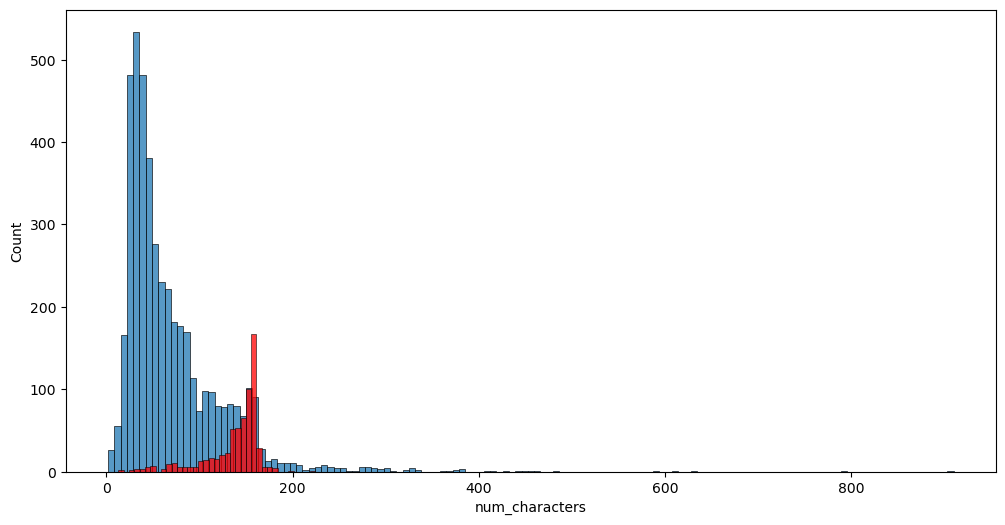

In [46]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red') 

<Axes: xlabel='num_words', ylabel='Count'>

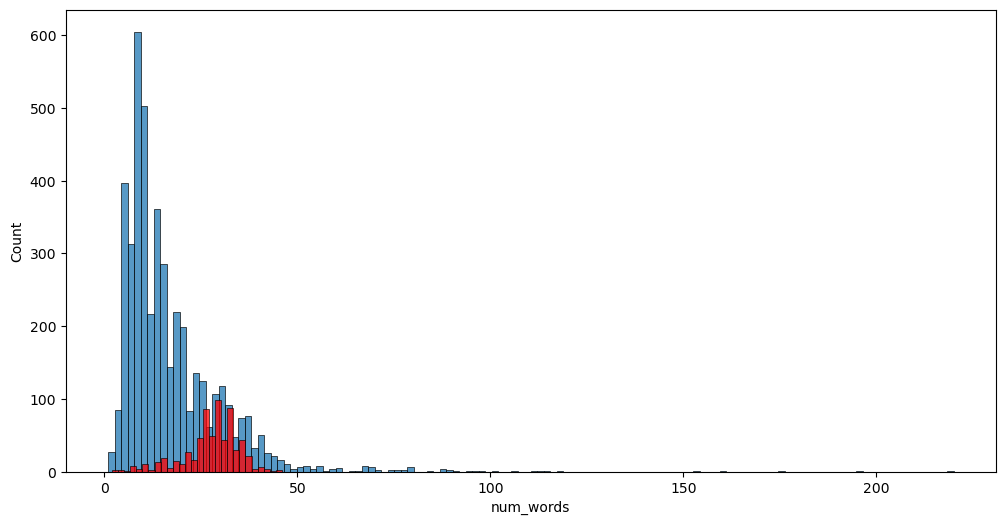

In [47]:
#to create histogram for ham and spam (FOR WORDS)
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

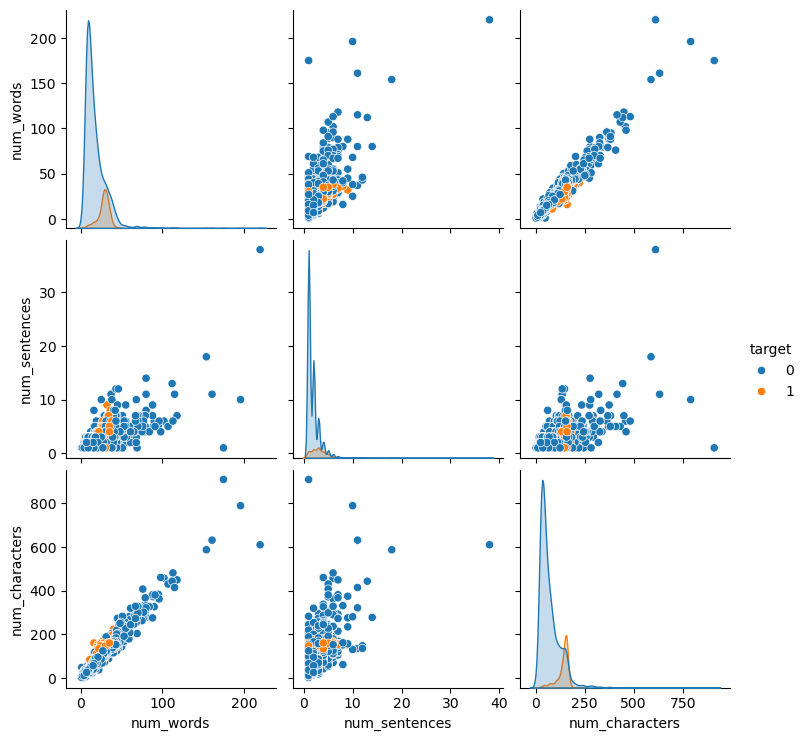

In [48]:
sns.pairplot(df,hue='target')

<Axes: >

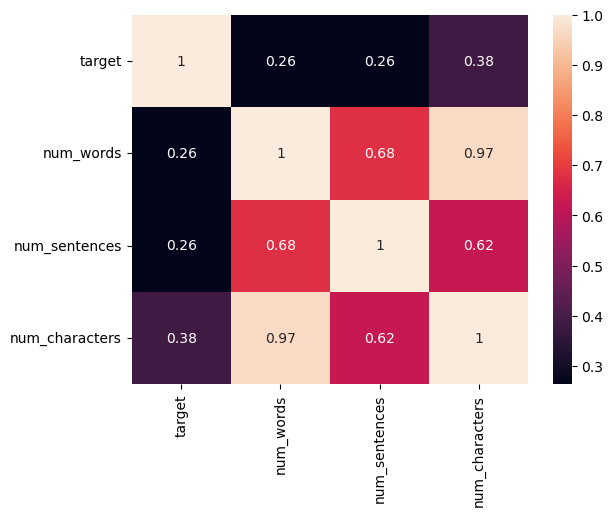

In [50]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## DATA PREPROCESSING
 * Lower case
 * Tokenization
 * Removing special characters
 * Removing stopwords and punctuation
 * Stemming

In [51]:
import nltk
nltk.download('stopwords')
def transform_text(text): 
  text = text.lower() 
  text = nltk.word_tokenize(text) 

  y = [] 
  for i in text: 
    if i.isalnum():
      y.append(i)


  text = y[:] 
  y.clear()
    
  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation: 
      y.append(i)

  text = y[:]
  y.clear()
    
  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)



[nltk_data] Downloading package stopwords to C:\Users\AYUSHI
[nltk_data]     TYAGI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [54]:
from nltk.corpus import stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [57]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [58]:
transform_text('Hey there! get 100$')

'hey get 100'

In [59]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [60]:
df['text'][10] #to see any text(msg) of our dataset at any no

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [61]:
df['transformed_text'] = df['text'].apply(transform_text)

In [64]:
df.head()

,target,text,num_words,num_sentences,num_characters,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",24,2,111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,8,2,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,2,155,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,13,1,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",15,1,61,nah think goe usf live around though


In [63]:
!pip install wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [65]:
from wordcloud import WordCloud 
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [66]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

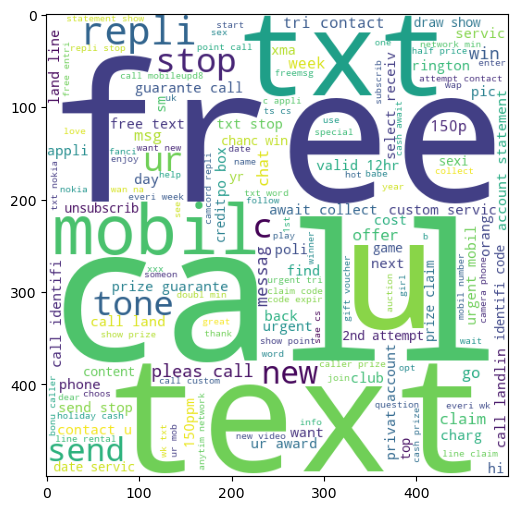

In [67]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [68]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

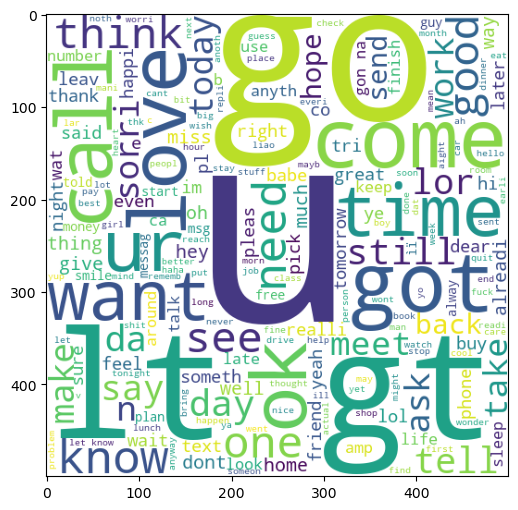

In [69]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [85]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [70]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split(): 
    spam_corpus.append(word)

In [71]:
len(spam_corpus)

9939

C:\Users\AYUSHI TYAGI\AppData\Local\Temp\ipykernel_14560\1366340694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30df[0], y=top_30df[1], palette='rainbow')


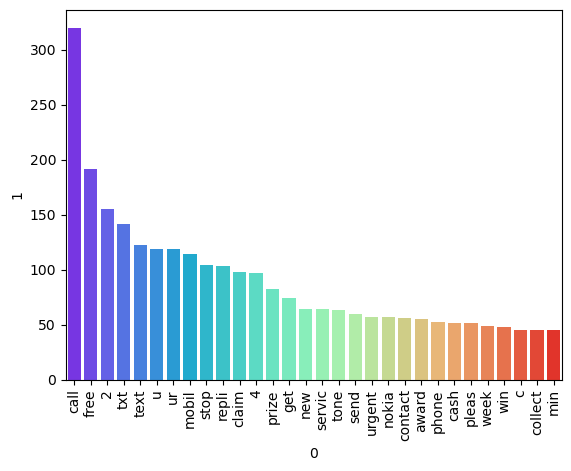

In [72]:
from collections import Counter
top_30df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=top_30df[0], y=top_30df[1], palette='rainbow')
plt.xticks(rotation='vertical') 
plt.show()

In [73]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [74]:
len(ham_corpus)

35404

C:\Users\AYUSHI TYAGI\AppData\Local\Temp\ipykernel_2540\2225182739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30df[0], y=top_30df[1], palette='viridis')


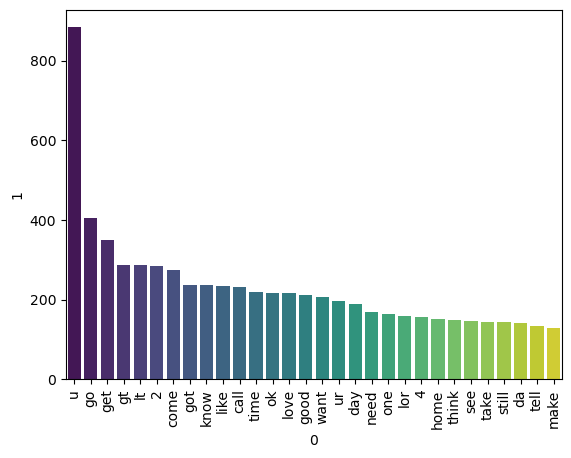

In [99]:
from collections import Counter
top_30df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=top_30df[0], y=top_30df[1], palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

## MODEL BUILDING

In [210]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [211]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [212]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [213]:
#appending the num_character column to x
#X = np.hstack((X, df['num_characters'].values.reshape(-1,1)))

In [214]:
X.shape

(5169, 3000)

In [215]:
y = df['target'].values

In [216]:
from sklearn.model_selection import train_test_split

In [217]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [218]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [219]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [220]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [221]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [222]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [223]:
# tfidf --> MNB

In [224]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [225]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5) 
lrc = LogisticRegression(solver='liblinear', penalty='l1') 
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2, algorithm='SAMME')
bc = BaggingClassifier(n_estimators=50, random_state=2) 
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2) 
xgb = XGBClassifier(n_estimators=50, random_state=2)

In [226]:
clfs = {            
     'SVC': svc,  
     'KN': knc,
     'NB': mnb,
     'DT': dtc,
     'LR': lrc,
     'RF': rfc,
     'AdaBoost': abc,
     'BgC': bc,
     'ETC': etc,
     'GBDT': gbdt,
     'xgb': xgb
}

In [227]:
def train_classifier (clf, X_train, y_train, X_test, y_test):
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test) 
  accuracy = accuracy_score(y_test, y_pred) 
  precision = precision_score(y_test, y_pred)

  return accuracy, precision

In [228]:
train_classifier(svc,X_train, y_train, X_test, y_test)

(0.9758220502901354, 0.9747899159663865)

In [ ]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items(): 
  current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)

  print("for" ,name)
  print("Accuracy- ", current_accuracy)
  print("Precision- ",current_precision)

  accuracy_scores.append(current_accuracy)  #storing the results in a list
  precision_scores.append(current_precision)

for SVC
Accuracy-  0.9758220502901354
Precision-  0.9747899159663865
for KN
Accuracy-  0.9052224371373307
Precision-  1.0
for NB
Accuracy-  0.9709864603481625
Precision-  1.0
for DT
Accuracy-  0.9323017408123792
Precision-  0.8333333333333334
for LR
Accuracy-  0.9584139264990329
Precision-  0.9702970297029703
for RF
Accuracy-  0.9758220502901354
Precision-  0.9829059829059829
for AdaBoost
Accuracy-  0.9245647969052224
Precision-  0.8488372093023255


In [188]:
performance_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy': accuracy_scores,'Precision': precision_scores}).sort_values('Precision', ascending=False) 

In [189]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.958414,0.970297
10,xgb,0.967118,0.948276
9,GBDT,0.946809,0.919192
7,BgC,0.958414,0.868217
6,AdaBoost,0.924565,0.848837


In [190]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [193]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.975822
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.958414
6,xgb,Accuracy,0.967118
7,GBDT,Accuracy,0.946809
8,BgC,Accuracy,0.958414
9,AdaBoost,Accuracy,0.924565


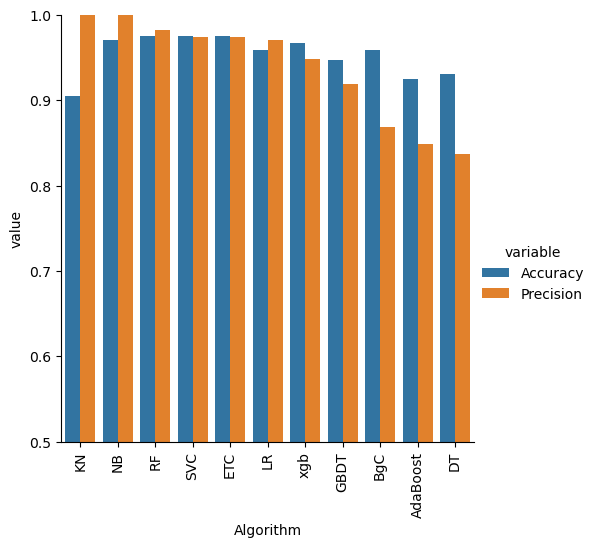

In [194]:
sns.catplot(x = 'Algorithm', y ='value',  
               hue= 'variable', data=performance_df1, kind='bar', height=5) 
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical') 

plt.show()

### MODEL IMPROVEMENT:
1. Change the max_features parameter of TfIdf to 3000  as original data might have 8000+ unique words many are noise that confuse model so we tell vectorizer only keep top 3000 most frequent words this makes maths matrix smaller and cleaner- ALREADY DONE ABOVE DURING NORMALIZATION
2. Scaling- from 0 to 1 to in vectorization but later comment out as multinomalNB works best with discrete counts or TF-IDF score when wescale(0,1) we sometimes lose weight or intensity of word count so accuracy drops model got confused by scaling called HEURISTICS in ml (KILL IMP PURI TARAH AGAR MAKING PROGRESS WORSE)
3. ADD NUM_CHAR WE MADE SHURU ME feature in input data (x)-- -- taking tdidf matrix (3000 word feature) and gluing num_char coln to it by adding msg length testing size of sms(metadata) is better tell than content(words)
3. voting classifier- creating combination of best performing classifiers and seeing if it outperform naivebayes all models look at an sms if two says spam and one ham majority wins
4. Stacking- taking o/p of models and give them to a final model usually logistic regression to make ultimate decision

In [195]:
performance_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy':accuracy_scores,'Precision':precision_scores}) 

In [196]:
temp_df = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}) 

In [159]:
temp_df_s = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores})

In [160]:
new_df = performance_df.merge(temp_df, on='Algorithm') 

In [161]:
new_df_scaled = new_df.merge(temp_df_s, on='Algorithm')

In [163]:
temp_df_num_chars = pd.DataFrame({'Algorithm': clfs.keys(), 'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars', ascending=False)

In [164]:
final_df = new_df_scaled.merge(temp_df_num_chars, on='Algorithm')

In [165]:
final_df

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling,Accuracy_num_chars,Precision_num_chars
0,SVC,0.866538,0.000000,0.866538,0.000000,0.866538,0.000000,0.866538,0.000000
1,KN,0.885880,0.833333,0.885880,0.833333,0.885880,0.833333,0.885880,0.833333
2,NB,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220,0.973888,0.951220
3,DT,0.942940,0.869159,0.942940,0.869159,0.942940,0.869159,0.942940,0.869159
4,LR,0.965184,0.955357,0.965184,0.955357,0.965184,0.955357,0.965184,0.955357
5,RF,0.969052,0.981818,0.969052,0.981818,0.969052,0.981818,0.969052,0.981818
6,AdaBoost,0.946809,0.902913,0.946809,0.902913,0.946809,0.902913,0.946809,0.902913
7,BgC,0.966151,0.899225,0.966151,0.899225,0.966151,0.899225,0.966151,0.899225
8,ETC,0.978723,0.975410,0.978723,0.975410,0.978723,0.975410,0.978723,0.975410
9,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693


In [197]:
#VOTING CLASSIFIER
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True) 
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [198]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)], voting='soft')

In [199]:
voting.fit(X_train, y_train) #training

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [200]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma =1.0, kernel ='sigmoid', 
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [201]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test, y_pred))
print("Precision",precision_score(y_test, y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


In [206]:
estimators = [('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [207]:
from sklearn.ensemble import StackingClassifier

In [208]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [209]:
clf.fit(X_train, y_train) 
y_pred = clf.predict(X_test) 
print("Stacking Accuracy", accuracy_score(y_test, y_pred)) 
print("Stacking Precision", precision_score(y_test, y_pred))

Stacking Accuracy 0.9806576402321083
Stacking Precision 0.9538461538461539


In [231]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))